In [ ]:
# !pip install implicit --upgrade

In [20]:
import os
import heapq
import implicit
import itertools
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from collections import namedtuple
from codecarbon import EmissionsTracker
from sklearn.metrics import pairwise_distances

In [21]:
# Lectura de datos de entrenamiento y validación
wk_train = pd.read_csv("wikimedia_train.csv")
wk_val = pd.read_csv("wikimedia_validation.csv")

In [22]:
# Transformamos la columna booleana en int (binario)
wk_train["evaluation"] = wk_train["evaluation"].astype(int)
wk_val["evaluation"] = wk_val["evaluation"].astype(int)

In [23]:
user_items_val = {}

for row in wk_val.itertuples():
    if row[1] not in user_items_val:
        user_items_val[row[1]] = []

    user_items_val[row[1]].append(row[2])

### Análisis exploratorio

In [24]:
# Resumen del dataset de entrenamiento
wk_train.describe()

,user_id,item_id,timestamp,evaluation
count,67806.000000,6.780600e+04,6.780600e+04,67806.000000
mean,3467.234183,2.012982e+08,1.369731e+09,0.000118
std,2047.236999,3.519299e+05,1.113170e+08,0.010861
min,1.000000,2.005010e+08,1.105491e+09,0.000000
25%,1706.000000,2.010081e+08,1.282098e+09,0.000000
50%,3714.000000,2.014022e+08,1.392957e+09,0.000000
75%,5049.000000,2.016031e+08,1.457634e+09,0.000000
max,7395.000000,2.019042e+08,1.556020e+09,1.000000


In [25]:
pd.DataFrame(data={
  "Statistic": [
    "Number of Users",
    "Number of Items",
    "Total Ratings",
    "Average Number of Ratings per User",
    "Average Number of Ratings per Item",
    "Highest Number of Ratings by a User",
    "Highest Number of Ratings for an Item",
    "Density"],
  "Training": [
    len(wk_train.drop_duplicates("user_id")),
    len(wk_train.drop_duplicates("item_id")),
    len(wk_train[wk_train["evaluation"] == 1]),
    wk_train.groupby("user_id")["evaluation"].sum().mean(),#wk_train[wk_train["evaluation"] == 1].groupby("user_id")["evaluation"].sum().mean(),
    wk_train.groupby("item_id")["evaluation"].sum().mean(),#wk_train[wk_train["evaluation"] == 1].groupby("item_id")["evaluation"].sum().mean(),
    wk_train.groupby("user_id")["evaluation"].sum().max(),#wk_train[wk_train["evaluation"] == 1].groupby("user_id")["evaluation"].sum().max(),
    wk_train.groupby("item_id")["evaluation"].sum().max(),#wk_train[wk_train["evaluation"] == 1].groupby("item_id")["evaluation"].sum().max(),
    100 * len(wk_train[wk_train["evaluation"] == 1]) / (len(wk_train.drop_duplicates("user_id")) * len(wk_train.drop_duplicates("item_id")))
    ],
  "Validation": [
    len(wk_val.drop_duplicates("user_id")),
    len(wk_val.drop_duplicates("item_id")),
    len(wk_val[wk_val["evaluation"] == 1]),
    wk_val.groupby("user_id")["evaluation"].sum().mean(),#wk_val[wk_val["evaluation"] == 1].groupby("user_id")["evaluation"].sum().mean(),
    wk_val.groupby("item_id")["evaluation"].sum().mean(),#wk_val[wk_val["evaluation"] == 1].groupby("item_id")["evaluation"].sum().mean(),
    wk_val.groupby("user_id")["evaluation"].sum().max(),#wk_val[wk_val["evaluation"] == 1].groupby("user_id")["evaluation"].sum().max(),
    wk_val.groupby("item_id")["evaluation"].sum().max(), #wk_val[wk_val["evaluation"] == 1].groupby("item_id")["evaluation"].sum().max(),
    100 * len(wk_val[wk_val["evaluation"] == 1]) / (len(wk_val.drop_duplicates("user_id")) * len(wk_val.drop_duplicates("item_id")))
    ]})

,Statistic,Training,Validation
0,Number of Users,1079.000000,1075.000000
1,Number of Items,9526.000000,5473.000000
2,Total Ratings,8.000000,11.000000
3,Average Number of Ratings per User,0.007414,0.010233
4,Average Number of Ratings per Item,0.000840,0.002010
5,Highest Number of Ratings by a User,1.000000,1.000000
6,Highest Number of Ratings for an Item,2.000000,1.000000
7,Density,0.000078,0.000187


### Preprocesamiento de los datos a formato sparse

In [26]:
# Código extraído de práctico 3
user_items = {}
itemset = set()

for row in wk_train.itertuples():
    if row[1] not in user_items:
        user_items[row[1]] = []

    user_items[row[1]].append(row[2])
    itemset.add(row[2])

itemset = np.sort(list(itemset))

sparse_matrix = np.zeros((len(user_items), len(itemset)))

for i, items in enumerate(user_items.values()):
    sparse_matrix[i] = np.isin(itemset, items, assume_unique=True).astype(int)

matrix = sparse.csr_matrix(sparse_matrix.T)

user_item_matrix = matrix.T.tocsr()

In [27]:
# Mapeo de user id a fila de la matriz sparse. Código extraído de práctico 3
user2row = {user_id: matrix_row for matrix_row, user_id in enumerate(user_items.keys())}
row2user = {matrix_row: user_id for user_id, matrix_row in user2row.items()}

# Mapeo de item id a columna de la matriz sparse. Código extraído de práctico 3
item2col = {item_id: matrix_col for matrix_col, item_id in enumerate(itemset)}
col2item = {matrix_col: item_id for item_id, matrix_col in item2col.items()}

In [28]:
# Cálculo de popularidad para poder obtener la novedad
item_pop = wk_train[wk_train["evaluation"] == 1].groupby("item_id").size()
item_pop /= item_pop.sum()
item_pop = item_pop.to_dict()

### Métricas

In [ ]:
# Definicion de métricas
def recall_at_k(r, k, total_relevant):
    assert 1 <= k <= r.size
    if total_relevant == 0:
        return 0
    return (np.asarray(r)[:k]).sum() / total_relevant

def novelty_at_k(r, p):
    nov = 0
    for item in r:
        pop = p.get(item, 1e-10)
        nov =+ np.log(1/pop)
    return nov

# Código siguiente extraído de práctico 3
def precision_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).mean()


def average_precision_at_k(r, k):
    r = np.asarray(r)
    n_rel = r.sum()  # Número de items relevantes
    if n_rel == 0:
        return 0.0
    vectorized_precision = np.vectorize(lambda i: precision_at_k(r, i))
    indices = np.arange(1, len(r) + 1)
    precisions = vectorized_precision(
        indices
    )  # Precision@k por cada posición del ranking
    score = np.sum(precisions * r)
    return score / min(k, n_rel)


def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(
            np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2))
        )
    return 0.0


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.0
    return dcg_at_k(r, k) / idcg

In [30]:
# Función para evaluar un modelo a partir de las métricas ya definididas. Código extraído de práctico 3
def evaluate_model(model, n):
    mean_recall = 0
    mean_ap = 0  # o MAP
    mean_ndcg = 0
    mean_novelty = 0

    for user_id in user_items_val.keys():
        user_row = user2row[user_id]
        rec = model.recommend(user_row, user_item_matrix[user_row], n)[0]
        rec = [col2item[col] for col in rec]
        rel_vector = np.isin(rec, user_items_val[user_id], assume_unique=True).astype(
            int
        )
        mean_recall += recall_at_k(rel_vector, n, len(user_items_val[user_id]))
        mean_ap += average_precision_at_k(rel_vector, n)
        mean_ndcg += ndcg_at_k(rel_vector, n)
        mean_novelty += novelty_at_k(rec, item_pop)

    mean_recall /= len(user_items_val)
    mean_ap /= len(user_items_val)
    mean_ndcg /= len(user_items_val)
    mean_novelty /= len(user_items_val)

    return mean_recall, mean_ap, mean_ndcg, mean_novelty

### ALS

In [34]:
# Cantidad de factores latentes
factors = [10, 50, 100, 150, 200]
# Factor de regularización
regs = [0.01, 0.05, 0.35]

# Definimos una tupla para almacenar las métricas
Metrics = namedtuple("Metrics", ["mrecall", "map", "ndcg", "mnovelty"])

als_perf = {}
als_em = []
# Entrenamos el modelo con optimización ALS para cada combinación de parametros
for factor, reg in itertools.product(factors, regs):
    # Medimos las emisiones de carbon para cada combinación de parametros
    tracker = EmissionsTracker(log_level="error")
    tracker.start()

    model_als = implicit.als.AlternatingLeastSquares(
        factors=factor, regularization=reg, iterations=15, use_gpu=False
    )
    model_als.fit(user_item_matrix)

    # Evaluamos el modelo con k=10
    mean_recall, mean_ap, mean_ndcg, mean_novelty = evaluate_model(model_als, 10)
    emissions = tracker.stop()
    als_em.append(emissions)

    als_perf[(factor, reg)] = Metrics(mean_recall, mean_ap, mean_ndcg, mean_novelty)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

In [35]:
print(f"Emisiones promedio durante el entrenamiento y evaluación del modelo ALS: {np.mean(als_em)}")

Emisiones promedio durante el entrenamiento y evaluación del modelo ALS: 1.7128121334612367e-05


In [36]:
# Mejor combinación de parametros segun MAP
sorted(als_perf.items(), key=lambda item: item[1].map, reverse=True)[0]

((200, 0.05),
 Metrics(mrecall=0.10949382822240127, map=0.06435119970468811, ndcg=0.08475831252793936, mnovelty=23.02585092994081))

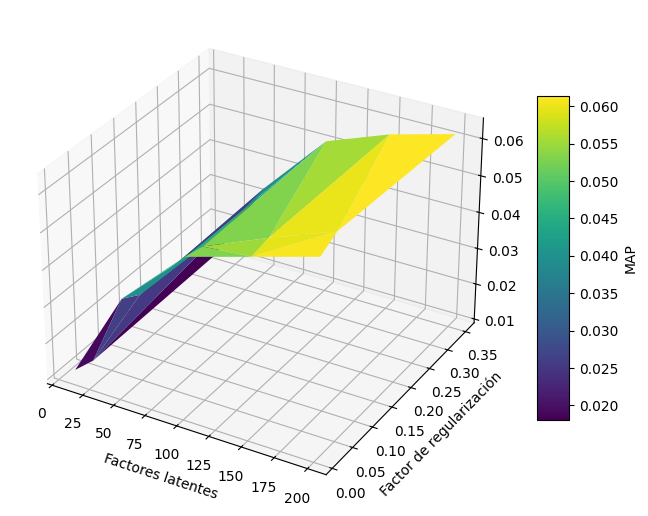

In [37]:
# Gráfico para evolución del MAP de acuerdo a cambios en los factores latentes y factor de regularización
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 7))
surf = ax.plot_trisurf([p[0] for p in als_perf.keys()], [p[1] for p in als_perf.keys()], [m.map for m in als_perf.values()], cmap="viridis")
fig.colorbar(surf, shrink=0.6, aspect=10, label="MAP")
ax.set_xlabel("Factores latentes")
ax.set_ylabel("Factor de regularización")
plt.show()

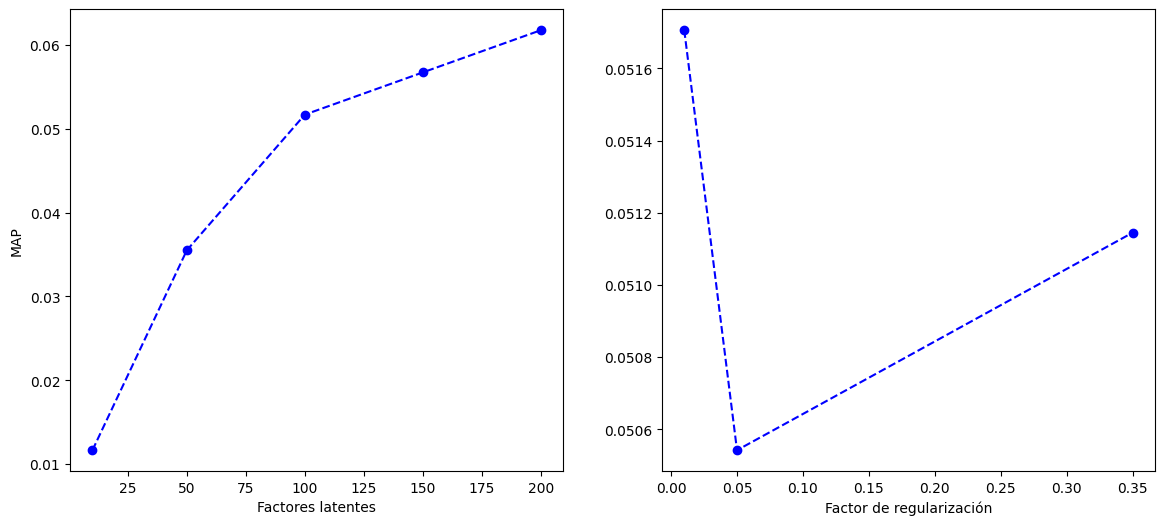

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graficamos el MAP a partir de la cantidad de factores latentes con factor de regularización fijo en 0.01
axes[0].plot([key[0] for key in als_perf.keys() if key[1] == 0.01], [als_perf[key].map for key in als_perf.keys() if key[1] == 0.01], "--bo")
axes[0].set_xlabel("Factores latentes")
axes[0].set_ylabel("MAP")
# Graficamos el MAP a partir del factor de regularización con 100 factores latentes
axes[1].plot([key[1] for key in als_perf.keys() if key[0] == 100], [als_perf[key].map for key in als_perf.keys() if key[0] == 100], "--bo")
axes[1].set_xlabel("Factor de regularización")
plt.show()

### BPR

In [39]:
# Learning rate
lrs = [0.01, 0.05, 0.25]

bpr_perf = {}
bpr_em = []

# Entrenamos el modelo con optimización BPR para cada combinación de parametros
for factor, reg, lr in itertools.product(factors, regs, lrs):
    # Medimos las emisiones de carbon cada combinación de parametros
    tracker = EmissionsTracker(log_level="error")
    tracker.start()

    model_bpr = implicit.bpr.BayesianPersonalizedRanking(
        factors=factor,
        regularization=reg,
        learning_rate=lr,
        iterations=40,
        use_gpu=False,
    )
    model_bpr.fit(user_item_matrix)

    # Evaluamos el modelo con k=10 
    mean_recall, mean_ap, mean_ndcg, mean_novelty = evaluate_model(model_bpr, 10)
    
    emissions = tracker.stop()
    bpr_em.append(emissions)

    bpr_perf[(factor, reg, lr)] = Metrics(mean_recall, mean_ap, mean_ndcg, mean_novelty)

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

In [40]:
print(f"Emisiones promedio durante el entrenamiento y evaluación del modelo BPR: {np.mean(bpr_em)}")

Emisiones promedio durante el entrenamiento y evaluación del modelo BPR: 6.264536111154716e-06


In [41]:
# Mejor combinación de parametros segun MAP
sorted(bpr_perf.items(), key=lambda item: item[1].map, reverse=True)[0]

((100, 0.01, 0.25),
 Metrics(mrecall=0.08181967280323263, map=0.04831112341577463, ndcg=0.06646350475706242, mnovelty=22.986880865962647))

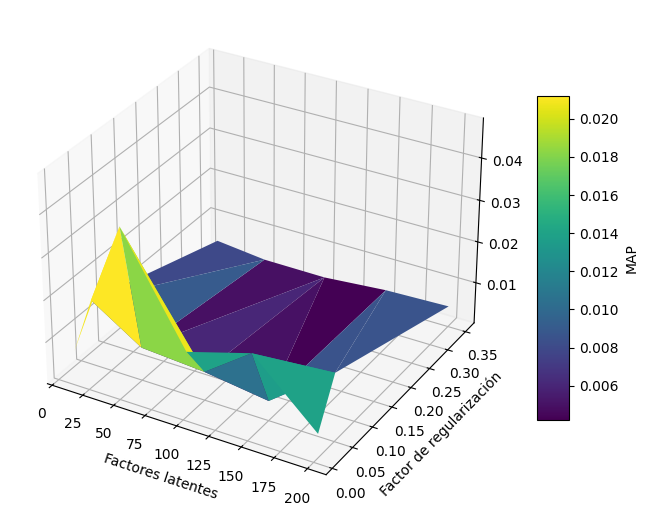

In [42]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 7))
# Gráfico para evolución del MAP de acuerdo a cambios en los factores latentes y factor de regularizaci[ón]
surf = ax.plot_trisurf([p[0] for p in bpr_perf.keys()], [p[1] for p in bpr_perf.keys()], [m.map for m in bpr_perf.values()], cmap="viridis")
fig.colorbar(surf, shrink=0.6, aspect=10, label="MAP")
ax.set_xlabel("Factores latentes")
ax.set_ylabel("Factor de regularización")
plt.show()

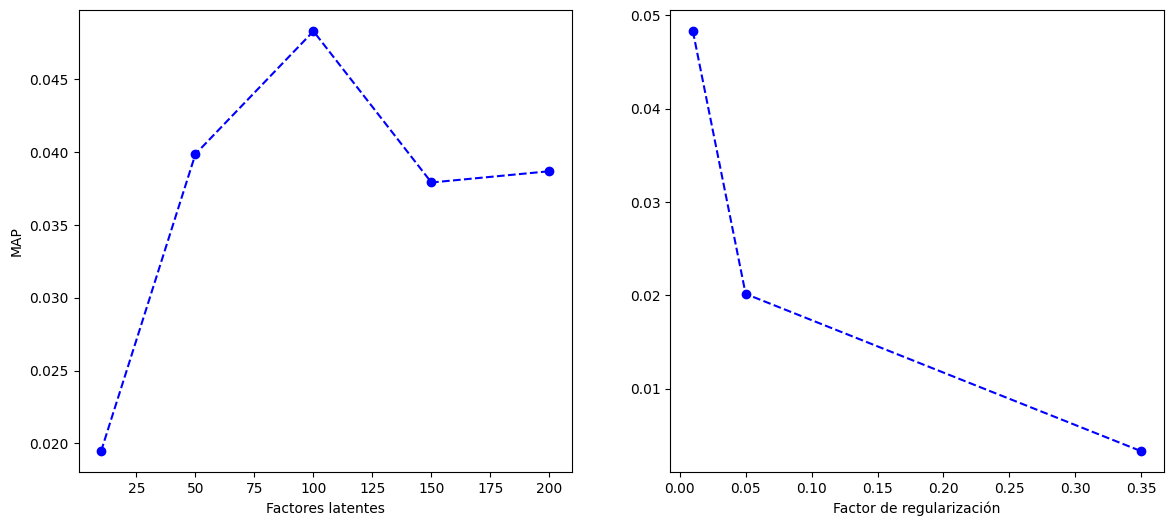

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graficamos el MAP a partir de la cantidad de factores latentes con factor de regularización fijo en 0.01
axes[0].plot(
    [key[0] for key in bpr_perf.keys() if (key[1] == 0.01 and key[2] == 0.25)],
    [
        bpr_perf[key].map
        for key in bpr_perf.keys()
        if (key[1] == 0.01 and key[2] == 0.25)
    ],
    "--bo",
)
axes[0].set_xlabel("Factores latentes")
axes[0].set_ylabel("MAP")
# Graficamos el MAP a partir del factor de regularización con 100 factores latentes
axes[1].plot(
    [key[1] for key in bpr_perf.keys() if (key[0] == 100 and key[2] == 0.25)],
    [
        bpr_perf[key].map
        for key in bpr_perf.keys()
        if (key[0] == 100 and key[2] == 0.25)
    ],
    "--bo",
)
axes[1].set_xlabel("Factor de regularización")
plt.show()

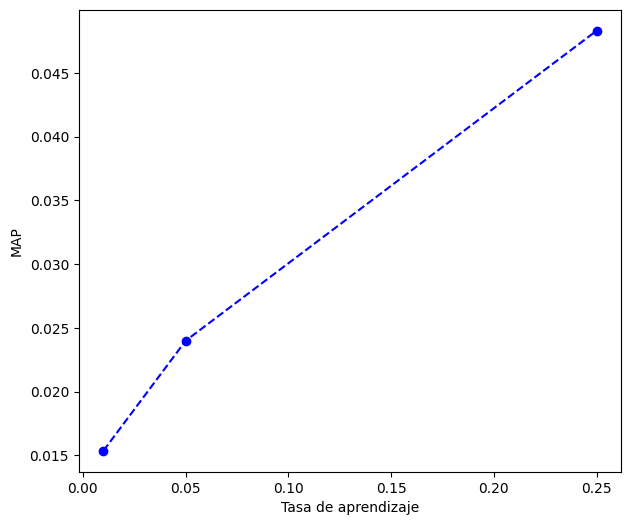

In [44]:
# Graficamos el MAP a partir del learning rate, con una cantidad fija de factores latentes y factor de regularización
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    [key[2] for key in bpr_perf.keys() if (key[1] == 0.01 and key[0] == 100)],
    [
        bpr_perf[key].map
        for key in bpr_perf.keys()
        if (key[1] == 0.01 and key[0] == 100)
    ],
    "--bo",
)

ax.set_xlabel("Tasa de aprendizaje")
ax.set_ylabel("MAP")

plt.show()

### Content-based

In [45]:
# Embeddings de imágenes
wk_emb = np.load("wikimedia_image_embeddings.npy")
# Mapeo de id de la imágen a indice en el array de embeddings
wk_id2idx = np.load("wikimedia_item_id_to_idx.npy", allow_pickle=True).item()
# Mapeo de indice del embedding de la imágen, a su id
wk_idx2id = {value: key for key, value in wk_id2idx.items()}

In [46]:
# Función para generar recomendaciones para usuarios. Basada en código de práctico 4
def content_recommend(embedding, user_id=None, topk=10, metric='cosine'):
    #user_id = str(user_id)

    trx = user_items[user_id]
    n = embedding.shape[0]
    distances = 1e9

    # Recorremos imagenes del set de entrenamiento que calificó el usuario
    for t in trx:
        query_i = wk_id2idx[t]

        # Recomendamos items más cercanos a items con los que interactuó el usuario
        distances = np.minimum(distances, pairwise_distances(
                embedding[query_i].reshape(1,-1), embedding, metric=metric).reshape(-1))

    # Rank items de menor a mayor distancia (nos quedamos con los top-k)
    trx_set = set(trx)
    heap = []
    for i in range(n):
        if wk_idx2id[i] in trx_set:
            continue
        if len(heap) < topk:
            heapq.heappush(heap, (-distances[i], i))
        else:
            heapq.heappushpop(heap, (-distances[i], i))
    heap.sort(reverse=True)

    # Utilizamos un heap para extraer los items ordenados de menor a mayor distancia
    recommended_ids = [wk_idx2id[i] for _,i in heap]

    # Retornar los que el usuario no haya consumido
    filtered_recommended_ids = []

    return recommended_ids

In [ ]:
# Evaluamos el recomendador utilizando los embeddings de ResNet
top_k = 10
cb_mean_ap = 0
cb_mean_ndcg = 0

tracker = EmissionsTracker(log_level="error")
tracker.start()

for user_id in user_items_val.keys():
    user_row = user2row[user_id]
    rec = content_recommend(wk_emb, user_id, top_k, "cosine")
    rel_vector = np.isin(rec, user_items_val[user_id], assume_unique=True).astype(int)

    mean_recall += recall_at_k(rel_vector, top_k, len(user_items_val[user_id]))
    mean_ap += average_precision_at_k(rel_vector, top_k)
    mean_ndcg += ndcg_at_k(rel_vector, top_k)
    mean_novelty += novelty_at_k(rec, item_pop)

cb_em = tracker.stop()

mean_recall /= len(user_items_val)
mean_ap /= len(user_items_val)
mean_ndcg /= len(user_items_val)
mean_novelty /= len(user_items_val)

In [ ]:
print(f"Emisiones durante la evaluación del recomendador basado en contenido: {cb_em}")

In [ ]:
print(f"Mean Recall@10: {mean_recall}")
print(f"MAP: {mean_ap}")
print(f"ndcg@10: {mean_ndcg}")
print(f"Novelty: {mean_novelty}")